In [1]:
from py_files.setup import *
setup_notebook()

# `GG-B`-like labour shares

*`1. plot differential`*

In [ ]:
# 1. get Leontif inverse values
years = range(1966, 2025)
df_ts = sls.load_or_compute_ls_timeseries(years, kappa=0.6)

Loading LS timeseries from 0_intermediate/direct_NX_cache/ls_timeseries_1966_2024.parquet …


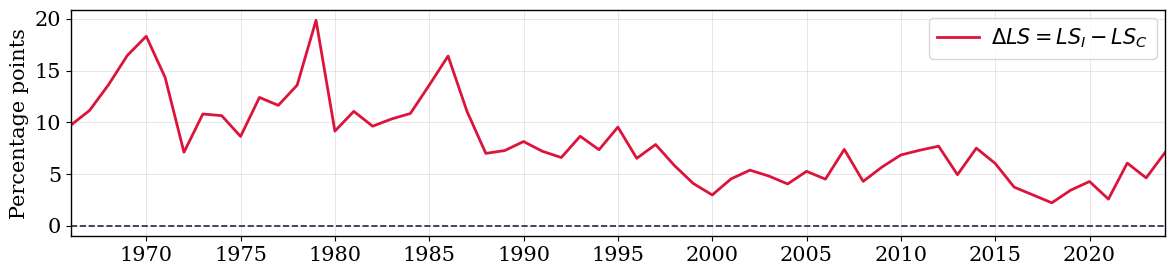

(<Figure size 1200x300 with 1 Axes>, <Axes: ylabel='Percentage points'>)

In [3]:
# 2. plot the difference between sectors
sls.plot_ls_difference(df_ts)

*`2. inspect and sanity`*

In [4]:
# 4. inspect industrylevel
diag = sls.inspect_year(2020)
diag[['direct_ls', 'consolidated_ls', 'w_C', 'w_I']]

Processing year 2020...


,direct_ls,consolidated_ls,w_C,w_I
parent,,,,
F,0.730906,0.730906,0.008403,0.393378
MA,0.742786,0.742786,0.001476,0.239099
G,0.624136,0.624136,0.136655,0.060869
CK,0.640436,0.640436,0.000439,0.034942
P,0.820632,0.820632,0.090542,0.033676
LA,0.189331,0.189331,0.002677,0.030483
MB,0.380567,0.380567,0.001426,0.026631
CF,0.209085,0.209085,0.001064,0.024337
JC,0.675686,0.675686,0.001528,0.024248


In [5]:
# 5. do weights sum to 1?
print(f"w_C sum: {diag['w_C'].sum():.4f}")
print(f"w_I sum: {diag['w_I'].sum():.4f}")

w_C sum: 1.0000
w_I sum: 1.0000


*` 3. create tabel for appendix`*

In [6]:
yr = il.load_or_compute_year(2024)
out_req = yr['output_requirements'].copy()
use_shares = yr['use_shares'].copy()
X = yr['X'].copy()

# add investment type classification
use_shares['investment_type'] = use_shares.index.map(var_groups.investment_type)
use_shares['parent'] = use_shares.index.map(var_groups.sub_to_parent)
out_req['parent'] = out_req.index.map(var_groups.sub_to_parent)
out_req['investment_type'] = out_req.index.map(var_groups.investment_type)

# split I into tangible and intangible at sub-industry level
tangible_types = ['structures', 'equipment']
intangible_types = ['intellectual_property', 'organizational']

out_req['I_tan']   = out_req['I'] * out_req['investment_type'].isin(tangible_types)
out_req['I_intan'] = out_req['I'] * out_req['investment_type'].isin(intangible_types)

# aggregate to parent
table = out_req.groupby('parent').sum()[['C', 'G', 'I_tan', 'I_intan', 'X']].copy()
table['total'] = table['C'] + table['G'] + table['I_tan'] + table['I_intan'] + table['X']
table['C (%)']     = ((table['C'] + table['G']) / table['total'] * 100).round(1)
table['Tangible (%)']  = (table['I_tan']   / table['total'] * 100).round(1)
table['Intangible (%)']= (table['I_intan'] / table['total'] * 100).round(1)
table['X (%)']     = (table['X'] / table['total'] * 100).round(1)

# size
gdp = il.fetch_gdp_data([2024]).iloc[0]
table['Uses/GDP (%)'] = (table['total'] / gdp * 100).round(1)

# labour shares
df_ls = sls.fetch_industry_labor_shares()
df_ls_yr = df_ls[df_ls['year'] == 2024]
ls_cons = sls.consolidated_labor_shares(yr, df_ls_yr)
ls_cons.index = ls_cons.index.map(var_groups.sub_to_parent)
ls_parent = ls_cons.groupby(ls_cons.index).mean()
table['LS (%)'] = (ls_parent * 100).round(1)

# names and final order
table['Industry'] = table.index.map(var_groups.large_dict)
table = table.set_index('Industry')
table = table[['Uses/GDP (%)', 'C (%)', 'Tangible (%)', 'Intangible (%)', 'X (%)', 'LS (%)']].round(1)
table

  Loading year 2024 from cache …


,Uses/GDP (%),C (%),Tangible (%),Intangible (%),X (%),LS (%)
Industry,,,,,,
"Agriculture, forestry and fishing",0.9,19.3,0.4,0.0,80.3,53.1
Mining and quarrying,0.3,2.0,3.0,0.0,95.0,27.5
"Manufacture of food products, beverages and tobacco",5.2,24.3,1.1,0.0,74.6,62.3
Textiles and leather products,0.3,14.5,3.2,0.0,82.3,66.2
Wood and paper products and printing,0.4,6.0,2.6,0.0,91.3,72.4
Oil refinery etc.,0.7,38.1,0.0,0.0,61.8,19.1
Manufacture of chemicals,1.5,2.3,5.9,0.0,91.8,31.0
Pharmaceuticals,11.2,0.4,0.0,8.1,91.6,14.7
"Manufacture of plastic, glass and concrete",0.7,7.2,2.5,0.0,90.3,62.2
